# 01 — PaddlePaddle Baseline

Runs PP-LCNet_x1_0_doc_ori using the native PaddlePaddle inference engine (PIR format, Paddle 3.x).
This is the **ground-truth baseline** — accuracy and latency all other runtimes are compared against.

Model: `models/PP-LCNet_x1_0_doc_ori_infer/`
Expected files:
- `inference.json`    ← PIR model (Paddle 3.x format)
- `inference.pdiparams`

In [1]:
import sys
sys.path.insert(0, '..')

import time
from pathlib import Path

import numpy as np
import pandas as pd
import paddle
from paddle.inference import Config, create_predictor
from tqdm import tqdm

from src.preprocess import load_and_preprocess

MODEL_DIR   = Path('../models/PP-LCNet_x1_0_doc_ori_infer')
DATASET_CSV = Path('../data/dataset.csv')
RESULTS_DIR = Path('../results')
RESULTS_DIR.mkdir(exist_ok=True)

print(f'PaddlePaddle version: {paddle.__version__}')
print(f'Model dir exists: {MODEL_DIR.exists()}')
print(f'Files: {[f.name for f in MODEL_DIR.iterdir()]}')

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/paddle/utils/cpp_extension/extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


PaddlePaddle version: 3.3.1
Model dir exists: True
Files: ['config.json', '._tmp', 'README.md', 'inference.json', '.msc', '.mv', 'inference.pdiparams', 'inference.yml']


In [2]:
# PIR format (Paddle 3.x): model file is inference.json, not inference.pdmodel
def build_predictor(model_dir: Path):
    config = Config(
        str(model_dir / 'inference.json'),
        str(model_dir / 'inference.pdiparams'),
    )
    config.disable_gpu()
    config.enable_mkldnn()
    config.set_cpu_math_library_num_threads(4)
    config.switch_ir_optim(True)
    return create_predictor(config)

predictor = build_predictor(MODEL_DIR)
input_names  = predictor.get_input_names()
output_names = predictor.get_output_names()
print('Inputs :', input_names)
print('Outputs:', output_names)

Inputs : ['x']
Outputs: ['fetch_name_0']


E0505 12:29:01.949277 155906176 analysis_config.cc:676] Please compile with ONEDNN first to use ONEDNN
I0505 12:29:01.951982 155906176 schema.cc:75] can't find dialect onednn_op's compress id, return original dialectname, it's better to insert compress id in DialectIdMap() func
--- Running PIR pass [add_shadow_output_after_dead_parameter_pass]
--- Running PIR pass [delete_quant_dequant_linear_op_pass]
--- Running PIR pass [delete_weight_dequant_linear_op_pass]
--- Running PIR pass [transfer_layout_pass]
--- Running PIR pass [common_subexpression_elimination_pass]
I0505 12:29:02.038683 155906176 print_statistics.cc:50] --- detected [5] subgraphs!
--- Running PIR pass [constant_folding_pass]
I0505 12:29:02.039284 155906176 pir_interpreter.cc:1606] New Executor is Running ...
I0505 12:29:02.039486 155906176 pir_interpreter.cc:1630] pir interpreter is running by multi-thread mode ...
I0505 12:29:02.042399 155906176 print_statistics.cc:44] --- detected [7, 260] subgraphs!
--- Running PIR pa

In [3]:
def predict(image_path: str) -> tuple[int, float]:
    tensor = load_and_preprocess(image_path)
    input_handle = predictor.get_input_handle(input_names[0])
    input_handle.reshape(tensor.shape)
    input_handle.copy_from_cpu(tensor)
    predictor.run()
    output = predictor.get_output_handle(output_names[0]).copy_to_cpu()
    pred_label = int(np.argmax(output, axis=1)[0])
    confidence = float(np.max(output))
    return pred_label, confidence

# Warm-up run
_ = predict(pd.read_csv(DATASET_CSV).iloc[0]['image_path'])
print('Predictor warmed up.')

Predictor warmed up.


I0505 12:29:02.091684 155906176 pir_interpreter.cc:1627] pir interpreter is running by trace mode ...


In [4]:
def predict(image_path: str) -> tuple[int, float]:
    tensor = load_and_preprocess(image_path)
    input_handle = predictor.get_input_handle(input_names[0])
    input_handle.reshape(tensor.shape)
    input_handle.copy_from_cpu(tensor)
    predictor.run()
    output = predictor.get_output_handle(output_names[0]).copy_to_cpu()
    pred_label = int(np.argmax(output, axis=1)[0])
    confidence = float(np.max(output))
    return pred_label, confidence

In [5]:
df = pd.read_csv(DATASET_CSV)

predictions, confidences, latencies = [], [], []

for row in tqdm(df.itertuples(), total=len(df), desc='PaddlePaddle inference'):
    t0 = time.perf_counter()
    pred, conf = predict(row.image_path)
    latencies.append((time.perf_counter() - t0) * 1000)  # ms
    predictions.append(pred)
    confidences.append(conf)

df['paddle_pred'] = predictions
df['paddle_conf'] = confidences
df['paddle_latency_ms'] = latencies
df.to_csv(RESULTS_DIR / 'paddle_results.csv', index=False)
print('Saved results/paddle_results.csv')

PaddlePaddle inference:   0%|          | 0/552 [00:00<?, ?it/s]

PaddlePaddle inference:   1%|          | 3/552 [00:00<00:21, 26.07it/s]

PaddlePaddle inference:   1%|          | 6/552 [00:00<00:19, 27.42it/s]

PaddlePaddle inference:   2%|▏         | 9/552 [00:00<00:20, 26.21it/s]

PaddlePaddle inference:   2%|▏         | 12/552 [00:00<00:20, 25.75it/s]

...

PaddlePaddle inference:  99%|█████████▊| 545/552 [00:21<00:00, 24.33it/s]

PaddlePaddle inference:  99%|█████████▉| 548/552 [00:21<00:00, 24.26it/s]

PaddlePaddle inference: 100%|█████████▉| 551/552 [00:21<00:00, 24.12it/s]

PaddlePaddle inference: 100%|██████████| 552/552 [00:21<00:00, 25.21it/s]

Saved results/paddle_results.csv


Accuracy:         0.9692
Avg latency:      39.53 ms
Throughput:       25.3 img/s

              precision    recall  f1-score   support

        0deg       0.96      0.99      0.97       138
       90deg       0.97      0.98      0.97       138
      180deg       0.97      0.95      0.96       138
      270deg       0.98      0.96      0.97       138

    accuracy                           0.97       552
   macro avg       0.97      0.97      0.97       552
weighted avg       0.97      0.97      0.97       552



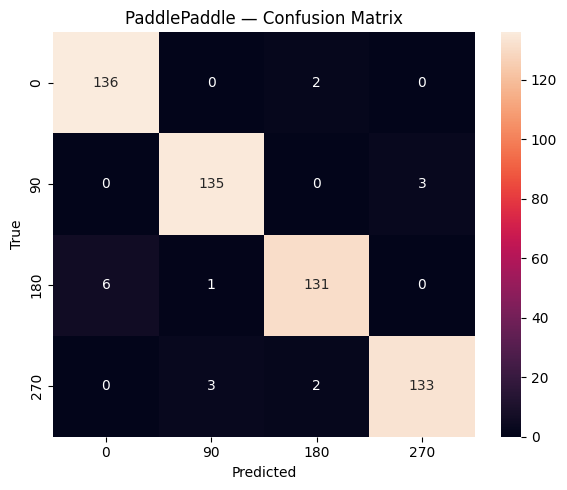

In [6]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

accuracy = (df['paddle_pred'] == df['label']).mean()
avg_latency = df['paddle_latency_ms'].mean()
throughput = 1000 / avg_latency

print(f'Accuracy:         {accuracy:.4f}')
print(f'Avg latency:      {avg_latency:.2f} ms')
print(f'Throughput:       {throughput:.1f} img/s')
print()
print(classification_report(df['label'], df['paddle_pred'],
                             target_names=['0deg','90deg','180deg','270deg']))

cm = confusion_matrix(df['label'], df['paddle_pred'])
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', ax=ax,
            xticklabels=['0','90','180','270'],
            yticklabels=['0','90','180','270'])
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('PaddlePaddle — Confusion Matrix')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'paddle_confusion_matrix.png', dpi=150)
plt.show()